In [94]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np 
from sklearn.preprocessing import LabelEncoder,StandardScaler,MinMaxScaler
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB

import warnings
warnings.filterwarnings('ignore')

In [95]:
df=pd.read_csv('Churn_Modelling.csv')
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [96]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)


In [97]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [98]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [99]:
df.duplicated().sum()

np.int64(0)

In [100]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.53,96.65,350.00,584.00,652.00,718.00,850.00
Age,10000.0,38.92,10.49,18.00,32.00,37.00,44.00,92.00
Tenure,10000.0,5.01,2.89,0.00,3.00,5.00,7.00,10.00
Balance,10000.0,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
NumOfProducts,10000.0,1.53,0.58,1.00,1.00,1.00,2.00,4.00
HasCrCard,10000.0,0.71,0.46,0.00,0.00,1.00,1.00,1.00
IsActiveMember,10000.0,0.52,0.50,0.00,0.00,1.00,1.00,1.00
EstimatedSalary,10000.0,100090.24,57510.49,11.58,51002.11,100193.92,149388.25,199992.48
Exited,10000.0,0.20,0.40,0.00,0.00,0.00,0.00,1.00


In [101]:
y=df['Exited']
y

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [102]:
df.drop(columns='Exited',inplace=True)

In [103]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


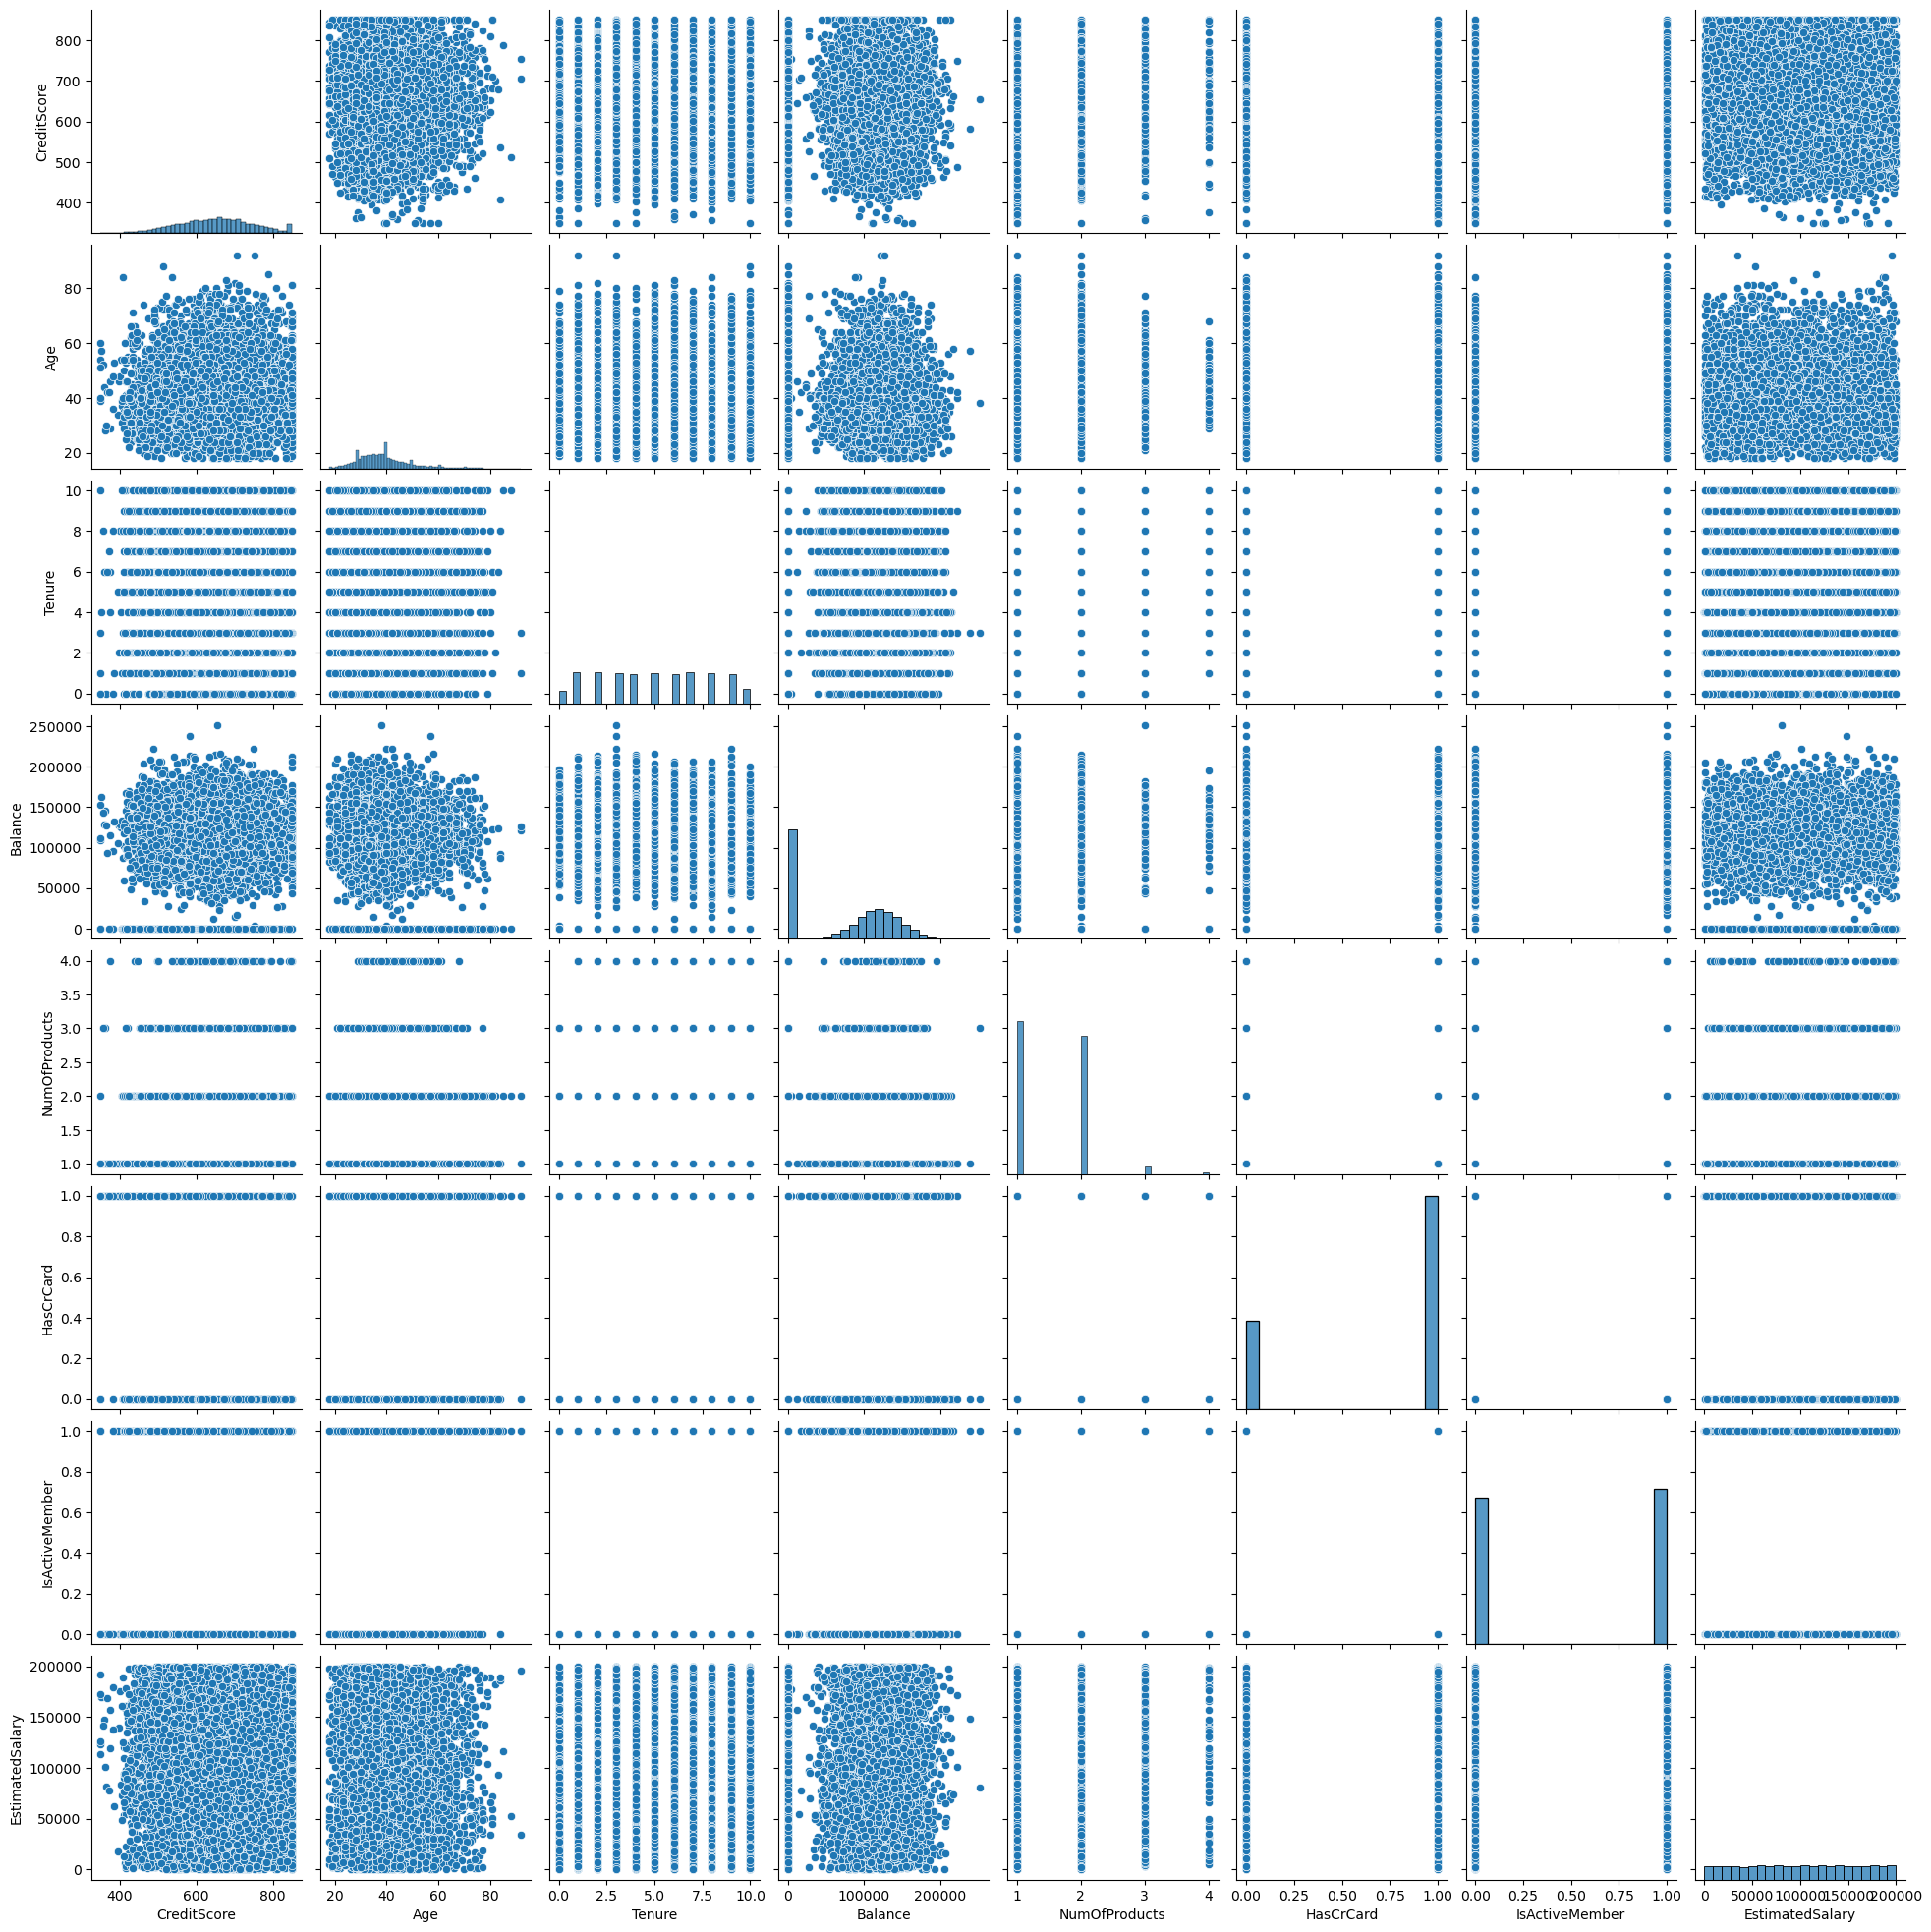

In [104]:
sns.pairplot(df)
plt.show()

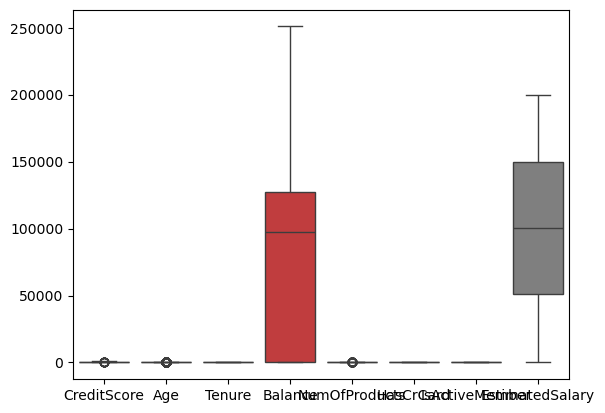

In [105]:
sns.boxplot(df)
plt.show()

In [106]:
nums_col=df.select_dtypes(include=['number']).columns
nums_col

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='object')

In [107]:
for i in nums_col:
    Q1=df[i].quantile(0.25)
    Q3=df[i].quantile(0.75)
    IQR=Q3-Q1
    # limits calculate karein 
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    outliers = df[(df[i] < lower_bound) | (df[i] > upper_bound)]
    print(outliers)
    # outliers ko min aur max limits 
    df[i]=df[i].clip(lower=lower_bound,upper=upper_bound)
    

      CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary
7             376   Germany  Female   29       4  115046.74              4          1               0        119346.88
942           376    France  Female   46       6       0.00              1          1               0        157333.69
1193          363     Spain  Female   28       6  146098.43              3          1               0        100615.14
1405          359    France  Female   44       6  128747.69              1          1               0        146955.71
1631          350     Spain    Male   54       1  152677.48              1          1               1        191973.49
1838          350   Germany    Male   39       0  109733.20              2          0               0        123602.11
1962          358     Spain  Female   52       8  143542.36              3          1               0        141959.11
2473          351   Germany  Female   57       4

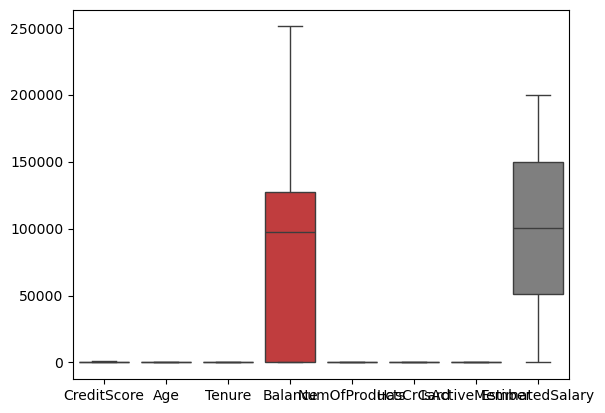

In [108]:
sns.boxplot(df)
plt.show()

In [109]:
df.value_counts(['Geography','Gender'])

Geography  Gender
France     Male      2753
           Female    2261
Spain      Male      1388
Germany    Male      1316
           Female    1193
Spain      Female    1089
Name: count, dtype: int64

In [110]:
object_col=df.select_dtypes(include=['O']).columns
object_col

Index(['Geography', 'Gender'], dtype='object')

In [111]:
X=pd.get_dummies(df,drop_first = True, dtype = int)
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1.0,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1.0,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3.0,1,0,113931.57,0,0,0
3,699,39,1,0.00,2.0,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1.0,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2.0,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1.0,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1.0,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2.0,1,0,92888.52,1,0,1


In [112]:
x__final=MinMaxScaler().fit_transform(X)
x__final

array([[0.50535332, 0.54545455, 0.2       , ..., 0.        , 0.        ,
        0.        ],
       [0.48179872, 0.52272727, 0.1       , ..., 0.        , 1.        ,
        0.        ],
       [0.25481799, 0.54545455, 0.8       , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.69807281, 0.40909091, 0.7       , ..., 0.        , 0.        ,
        0.        ],
       [0.83297645, 0.54545455, 0.3       , ..., 1.        , 0.        ,
        1.        ],
       [0.875803  , 0.22727273, 0.4       , ..., 0.        , 0.        ,
        0.        ]], shape=(10000, 11))

In [113]:
X_final=StandardScaler().fit_transform(X)
X_final

array([[-0.32687761,  0.34261499, -1.04175968, ..., -0.57873591,
        -0.57380915, -1.09598752],
       [-0.44080365,  0.24001108, -1.38753759, ..., -0.57873591,
         1.74273971, -1.09598752],
       [-1.53863634,  0.34261499,  1.03290776, ..., -0.57873591,
        -0.57380915, -1.09598752],
       ...,
       [ 0.60524449, -0.27300849,  0.68712986, ..., -0.57873591,
        -0.57380915, -1.09598752],
       [ 1.25772996,  0.34261499, -0.69598177, ...,  1.72790383,
        -0.57380915,  0.91241915],
       [ 1.4648682 , -1.09383981, -0.35020386, ..., -0.57873591,
        -0.57380915, -1.09598752]], shape=(10000, 11))

In [114]:
X_final.shape

(10000, 11)

In [115]:
# Separate Features & Target columns
x=x__final

In [116]:
# Splitting into training & testing sets
X_train,X_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)

In [117]:
# Separate Features & Target columns
X=X_final

In [118]:
# Splitting into training & testing sets
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=42)

## 1.  initializing Logistic Regression class 

In [119]:
model=LogisticRegression()

In [120]:
# training the model
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [121]:
y_pred=model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [122]:
accuracyscore=accuracy_score(y_test,y_pred)
print(accuracyscore)
print("\nClassification Report:\n",classification_report(y_test,y_pred))

0.8165

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.96      0.89      1607
           1       0.58      0.24      0.34       393

    accuracy                           0.82      2000
   macro avg       0.71      0.60      0.61      2000
weighted avg       0.79      0.82      0.78      2000



In [123]:
conf_matrix_Log=confusion_matrix(y_test,y_pred)
conf_matrix_Log

array([[1540,   67],
       [ 300,   93]])

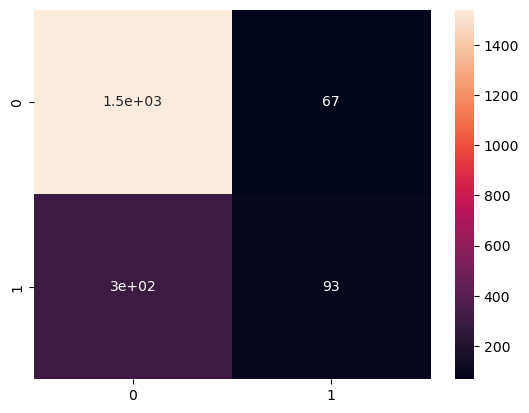

In [124]:
sns.heatmap(conf_matrix_Log,annot=True)
plt.show()

## 2.  Support Vector Classifier(SVC)

In [125]:
# create & training the model 
Classifier=SVC()

In [126]:
Classifier.fit(X_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [127]:
y_pred_C=Classifier.predict(X_test)
y_pred_C

array([0, 0, 0, ..., 1, 0, 0], shape=(2000,))

In [128]:
accuracy__score=accuracy_score(y_test,y_pred_C)
print(accuracy__score)
print('classification_report',classification_report(y_test,y_pred_C))

0.858
classification_report               precision    recall  f1-score   support

           0       0.87      0.97      0.92      1607
           1       0.79      0.38      0.51       393

    accuracy                           0.86      2000
   macro avg       0.83      0.68      0.72      2000
weighted avg       0.85      0.86      0.84      2000



In [129]:
conf_matrix_C=confusion_matrix(y_test,y_pred_C)
conf_matrix_C

array([[1566,   41],
       [ 243,  150]])

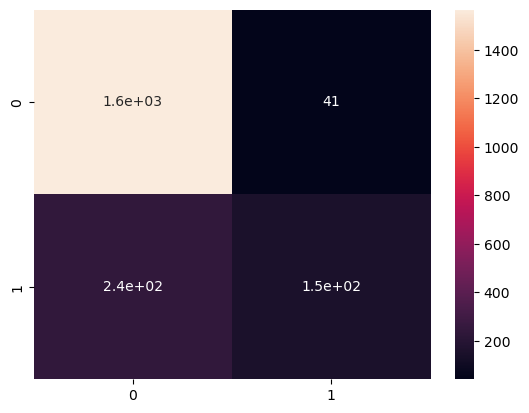

In [130]:
sns.heatmap(conf_matrix_C,annot=True)
plt.show()

## 3.  DecisionTreeClassifier

In [131]:
# create & training the model 
Classifier_D=DecisionTreeClassifier()

In [132]:
Classifier_D.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [133]:
y_pred_D=Classifier_D.predict(X_test)
y_pred_D

array([1, 0, 0, ..., 1, 0, 1], shape=(2000,))

In [134]:
accuracy_score_D=accuracy_score(y_test,y_pred_D)
print(accuracy_score_D)
print('classification_report',classification_report(y_test,y_pred_D))

0.7795
classification_report               precision    recall  f1-score   support

           0       0.88      0.85      0.86      1607
           1       0.45      0.51      0.48       393

    accuracy                           0.78      2000
   macro avg       0.66      0.68      0.67      2000
weighted avg       0.79      0.78      0.78      2000



In [135]:
conf_matrix_D=confusion_matrix(y_test,y_pred_D)
conf_matrix_D

array([[1359,  248],
       [ 193,  200]])

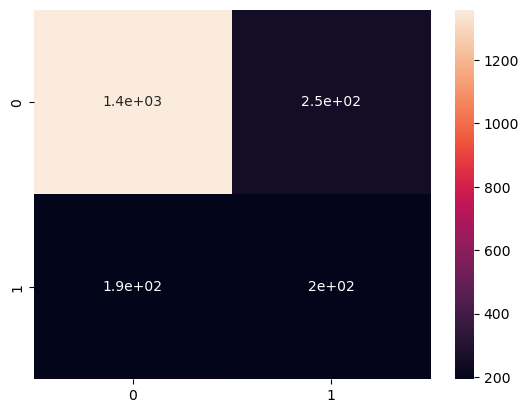

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

In [136]:
sns.heatmap(conf_matrix_D,annot=True)
plt.show()
plt.figure(figsize=(10,8))

## 4.   RandomForestClassifier

In [137]:
# Create & train the Model
model_class=RandomForestClassifier(n_estimators=100)    #  default n_estimators 200 hote hai 

In [138]:
model_class.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [139]:
y_pred_class=model_class.predict(X_test)
y_pred_class

array([0, 0, 0, ..., 1, 0, 1], shape=(2000,))

In [140]:
accuracy_score_class=accuracy_score(y_test,y_pred_class)
print(accuracy_score_class)
print('classification_report',classification_report(y_test,y_pred_class))

0.868
classification_report               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



## 5.   KNeighborsClassifier

In [141]:
# Create & train the Model
Classifier_KN=KNeighborsClassifier(n_neighbors=5)

In [142]:
Classifier_KN.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [143]:
y_pred_KN=Classifier_KN.predict(X_test)
y_pred_KN

array([0, 0, 0, ..., 1, 0, 0], shape=(2000,))

In [144]:
accuracy_score_KN=accuracy_score(y_test,y_pred_KN)
print(accuracy_score_KN)
print('classification_report',classification_report(y_test,y_pred_KN))

0.833
classification_report               precision    recall  f1-score   support

           0       0.86      0.94      0.90      1607
           1       0.62      0.38      0.47       393

    accuracy                           0.83      2000
   macro avg       0.74      0.66      0.69      2000
weighted avg       0.81      0.83      0.82      2000



In [145]:
conf_matrix_kn=confusion_matrix(y_test,y_pred_KN)
conf_matrix_kn

array([[1517,   90],
       [ 244,  149]])

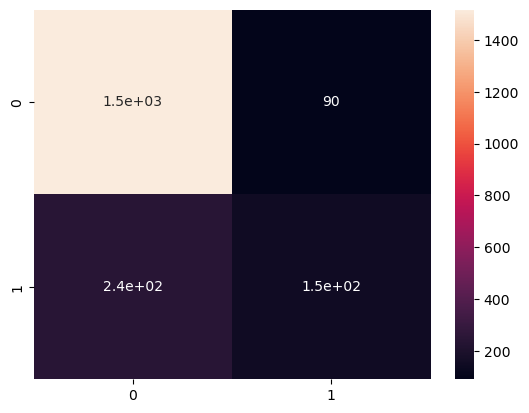

In [146]:
sns.heatmap(conf_matrix_kn,annot=True)
plt.show()

## 6.    GaussianNB

In [147]:
# Create & train the Model
model_G=GaussianNB()

In [148]:
model_G.fit(X_train,y_train)

,priors,None
,var_smoothing,1e-09


In [149]:
y_pred_G=model_G.predict(X_test)
y_pred_G

array([0, 0, 0, ..., 0, 0, 0], shape=(2000,))

In [150]:
accuracy_score_G=accuracy_score(y_test,y_pred_G)
print(accuracy_score_G)
print('classification_report',classification_report(y_test,y_pred_G))

0.8355
classification_report               precision    recall  f1-score   support

           0       0.86      0.95      0.90      1607
           1       0.64      0.37      0.47       393

    accuracy                           0.84      2000
   macro avg       0.75      0.66      0.69      2000
weighted avg       0.82      0.84      0.82      2000



## confusion matrix
*confision matrix is a table which is used to evaluate classification models.

In [151]:
conf_matrix=confusion_matrix(y_test,y_pred_G)
conf_matrix

array([[1526,   81],
       [ 248,  145]])

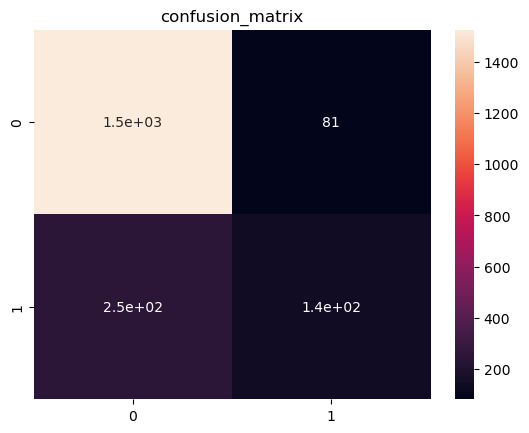

In [152]:
sns.heatmap(conf_matrix,annot=True)
plt.title('confusion_matrix')
plt.show()

## 7.  MultinomialNB

In [153]:
# Create & train the Model
model_M=MultinomialNB()

In [154]:
model_M.fit(X_train,y_train)

ValueError: Negative values in data passed to MultinomialNB (input X).

In [ ]:
y_pred_M=model_M.predict(X_test)
y_pred_M

In [ ]:
accuracy_score_M=accuracy_score(y_test,y_pred_M)
print(accuracy_score_M)
print('classification_report',classification_report(y_test,y_pred_M))

## confusion matrix

In [ ]:
confu_matrix=confusion_matrix(y_test,y_pred_M)
confu_matrix

In [ ]:
sns.heatmap(confu_matrix,annot=True)
plt.title('confusion_matrix')
plt.show()

In [ ]:
import pickle

In [155]:
with open('churn_model.pkl','wb') as f:
    pickle.dump(model_class,f)
print('model saved Successfully!')

model saved Successfully!
